In [35]:
from matplotlib import pyplot as plt
from serial import SerialException
import enum
import numpy as np

from discovery import Discovery
from driver import Driver
from load_pickle import load

try:
    Encryption_Board = Driver()
    Oscilloscope = Discovery()
except SerialException:
    print("Encryption board not found. Please check the connection.")
except SystemExit:
    print("Oscilloscope not found. Please check the connection.")

# Setup reading channels for the oscilloscope
class CHANNELS(enum.Enum):
    POWER_CONSUMPTION = 0
    SBOX_ACCESS_TRIGGER = 1
    ENCRYPTION_START_TRIGGER = 2
    CH3 = 3
    CH4 = 4

-> Synchronization error. Aborting...
Oscilloscope not found. Please check the connection.


In [36]:
import random

def generateRandomPlaintext() -> int:
    return random.getrandbits(128)

def plotCurrentWaveform(measure: np.ndarray):
    plt.plot(measure)
    plt.xlabel("Time (ms)")
    plt.ylabel("Current (mA)")
    plt.title("Current waveform")
    plt.show()

## Board Functions

In [37]:
def encryptPlaintext(plaintext: int) -> int:
    ciphertext = Encryption_Board.encrypt(plaintext)
    return ciphertext

## Oscilloscope functions

In [44]:
def measureCurrent(measure: np.ndarray, rise: int, fall: int) -> float:
    """
    Digital pin 5:
        Rise: begin of 1st stage sbox calculation
        Fall: end of 1st stage sbox calculation
    """
    return measure[rise:fall].mean()

def prepareOscilloscope(channel: CHANNELS = CHANNELS.SBOX_ACCESS_TRIGGER):
    """
    Activates the specified channel as trigger to the readings
    if no <channel> is specified, the default is SBOX_ACCESS_TRIGGER
    """
    if channel is CHANNELS.SBOX_ACCESS_TRIGGER:
        Oscilloscope.configure() # Activate channel 0 and 1
    else:
        Oscilloscope.enableChannel(0)
        Oscilloscope.setMode('normal')
        Oscilloscope.enableChannel(channel.value)
        Oscilloscope.setOffset(channel.value, 0.0)
        Oscilloscope.setTriggerEdge(channel.value, 1, "rising")
    
    # Start the oscilloscope to be ready for readings
    Oscilloscope.run()

def waitForAcquisitionDone():
    while not Oscilloscope.isReady():
        pass

def getOscilloscopeReadings(channel: CHANNELS=CHANNELS.POWER_CONSUMPTION) -> np.ndarray:
    return np.array(
        Oscilloscope.getSamples(channel.value)
    )

from tqdm import tqdm
def measurePowerTraces(num: int) -> tuple[list[int], np.ndarray]:
    T: list[int] = []
    M: np.ndarray = np.zeros((num, 8192))
    for i in tqdm(range(num)):
        plaintext = generateRandomPlaintext()
        T.append(plaintext)

        prepareOscilloscope(CHANNELS.SBOX_ACCESS_TRIGGER)
        ciphertext = Encryption_Board.encrypt(plaintext)
        waitForAcquisitionDone()
        M[i] = getOscilloscopeReadings(CHANNELS.POWER_CONSUMPTION)
    Oscilloscope.close()
    return T, M

# CPA Attack

In [39]:
def hamming_distance(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """
    Calculate the Hamming distance between two arrays of binary strings.
    A XOR B, then convert to bits and sum the number of 1s in each row
    """
    xor = np.bitwise_xor(a, b)
    bits_representation = np.unpackbits(xor, axis=1)
    hamming_distance = bits_representation.sum(axis=1)
    return hamming_distance.reshape(-1, 1) # Convert to column vector

# Attack using provided powertraces

In [40]:
plaintexts: list[int]
M: np.ndarray
plaintexts, M = load("./testsca.pickle")

In [41]:
print(len(plaintexts), M.shape)
print(plaintexts[0])

500 (500, 4000)
8178686806597379442190969825167098279


## CPA Implementation

Byte 0: Guess = 75, Correlation = 0.9286
Byte 1: Guess = e8, Correlation = 0.9440
Byte 2: Guess = cc, Correlation = 0.9314
Byte 3: Guess = 74, Correlation = 0.9392
Byte 4: Guess = 97, Correlation = 0.9437
Byte 5: Guess = f7, Correlation = 0.9029
Byte 6: Guess = 46, Correlation = 0.9513
Byte 7: Guess = a9, Correlation = 0.9624
Byte 8: Guess = e4, Correlation = 0.9305
Byte 9: Guess = 76, Correlation = 0.9390
Byte 10: Guess = 80, Correlation = 0.9756
Byte 11: Guess = 99, Correlation = 0.9552
Byte 12: Guess = 71, Correlation = 0.9501
Byte 13: Guess = 84, Correlation = 0.8710
Byte 14: Guess = 17, Correlation = 0.9196
Byte 15: Guess = e4, Correlation = 0.8845


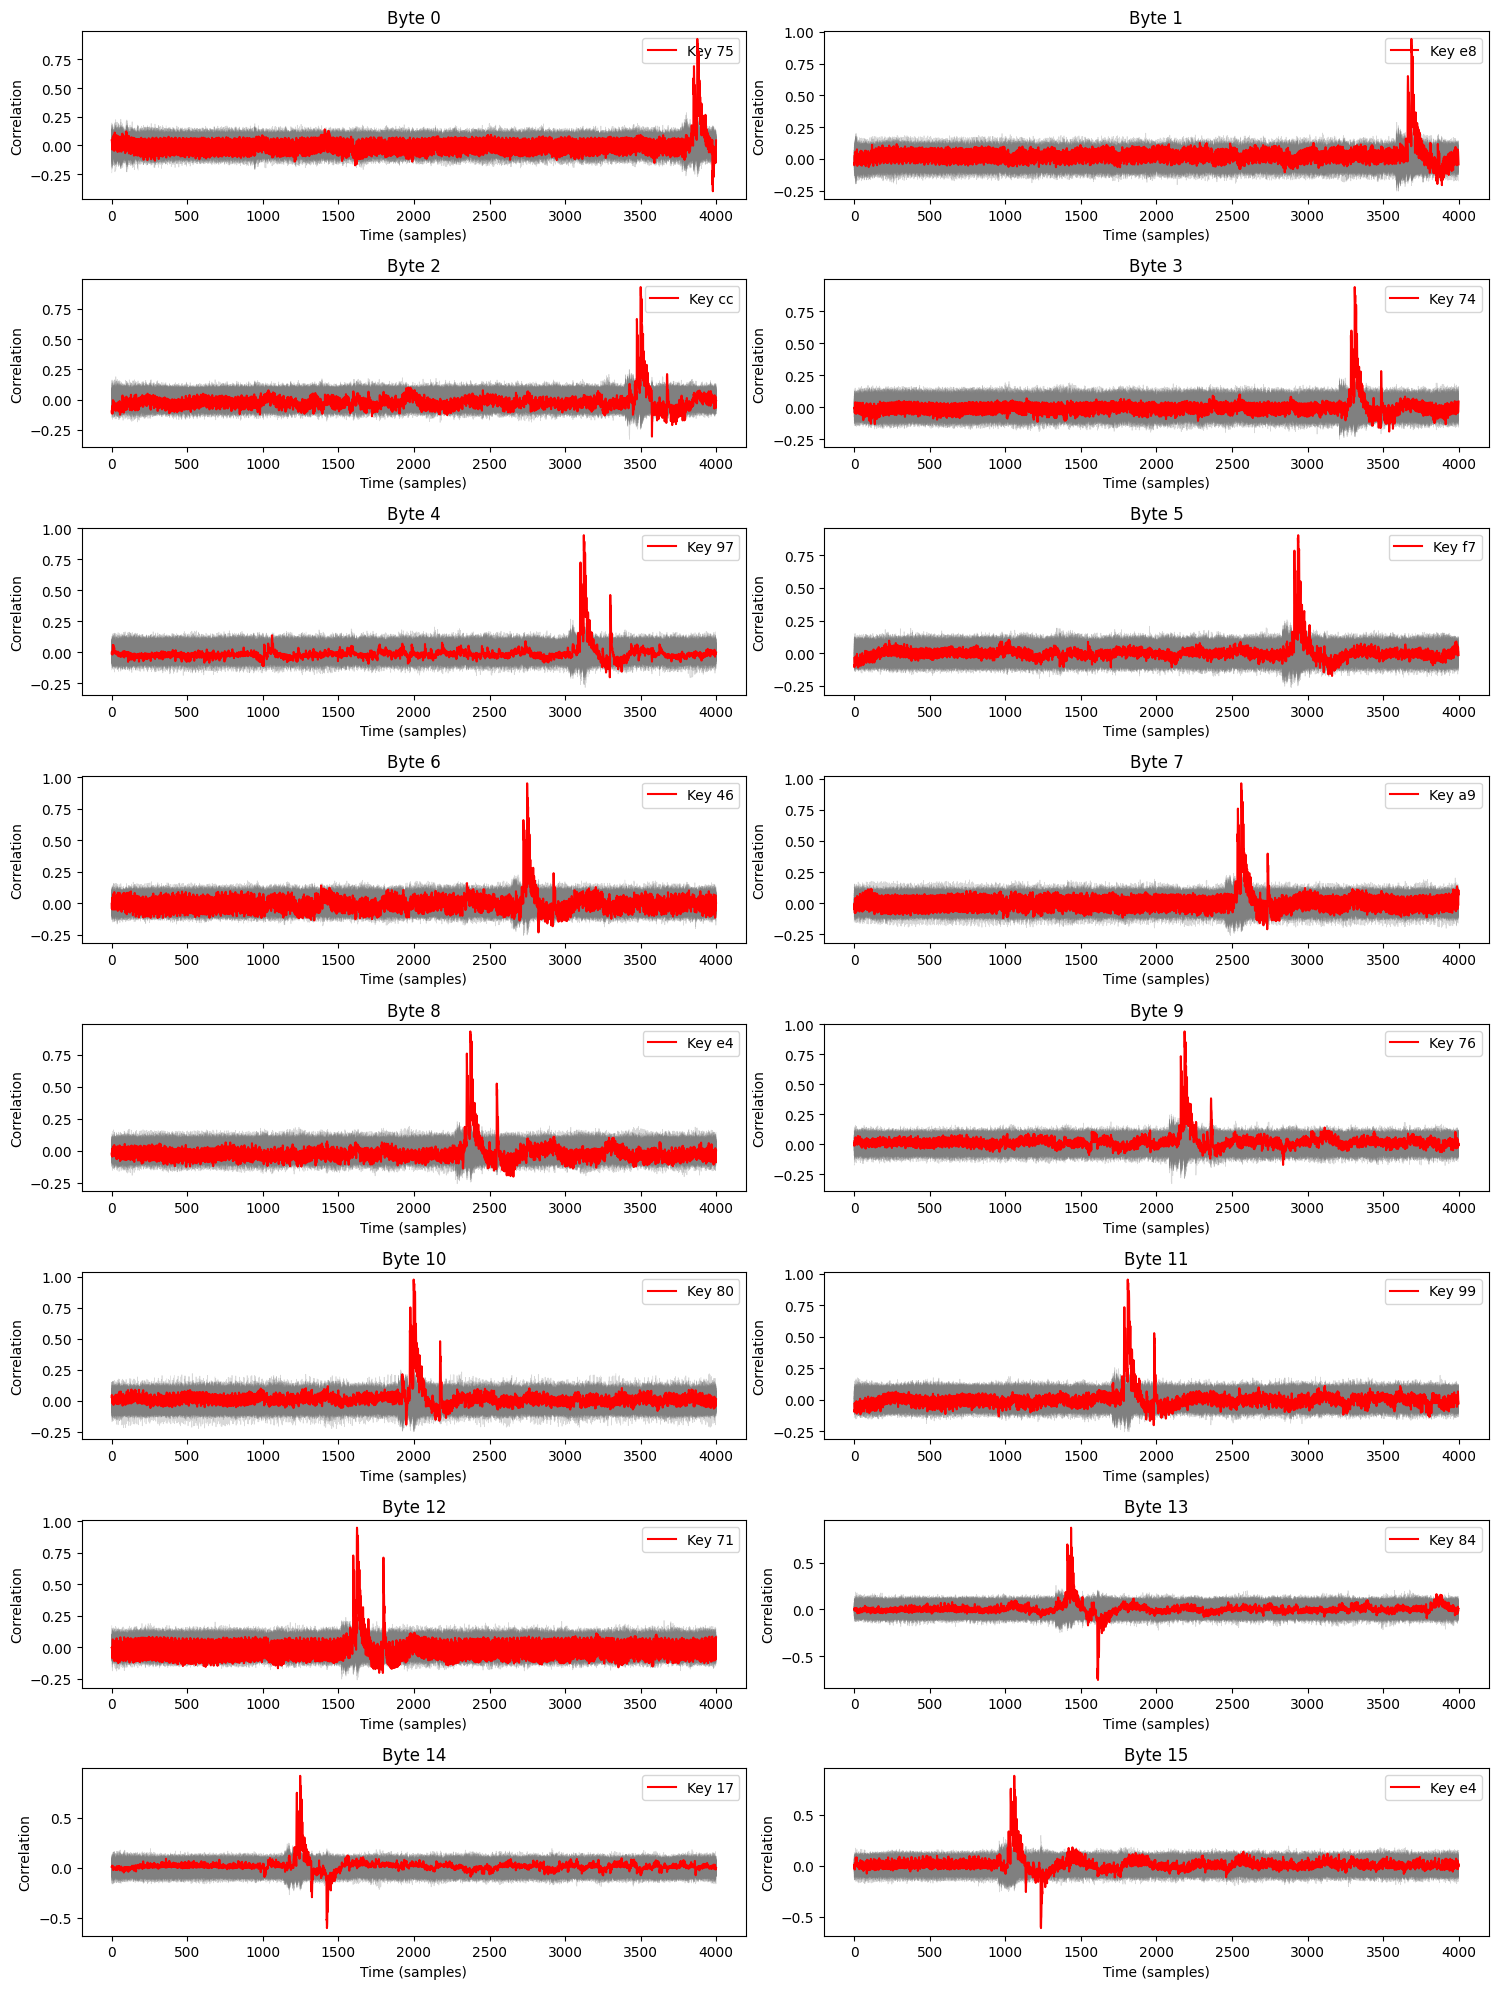

Recovered key: 75e8cc7497f746a9e4768099718417e4


In [42]:
from aes_sbox import SBOX

SBOX_ARRAY = np.array(SBOX, dtype=np.uint8)
HW_TABLE = np.array([bin(x).count("1") for x in range(256)], dtype=np.uint8)

def extract_plaintext_bytes(plaintexts: list[int]) -> np.ndarray:
    pt_bytes = np.zeros((len(plaintexts), 16), dtype=np.uint8)
    for i, p in enumerate(plaintexts):
        for b in range(16):
            shift = 8 * (15 - b)
            pt_bytes[i, b] = (p >> shift) & 0xFF
    return pt_bytes


def predictCurrent(plaintext_byte: np.uint8, key_guess: np.uint8) -> np.uint8:
    return HW_TABLE[SBOX_ARRAY[plaintext_byte ^ key_guess]] # type: ignore

def generatePredictedCurrents(plaintexts_byte: np.ndarray) -> np.ndarray:
    num_traces = plaintexts_byte.shape[0]
    predictions = np.empty((num_traces, 256), dtype=np.uint8)
    for key in np.arange(256, dtype=np.uint8):
        for i, pt in enumerate(plaintexts_byte):
            predictions[i, key] = predictCurrent(pt, key)
    return predictions

def computePearsonCoefficient(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    N = a.shape[0]
    a = a.astype(np.float64)
    b = b.astype(np.float64)

    numerator = N * (a.T @ b) - a.sum(axis=0).reshape(-1, 1) * b.sum(axis=0).reshape(1, -1)  # (K, T)
    std_a = np.sqrt(N * (a**2).sum(axis=0) - a.sum(axis=0)**2).reshape(-1, 1)  # (K, 1)
    std_b = np.sqrt(N * (b**2).sum(axis=0) - b.sum(axis=0)**2).reshape(1, -1)  # (1, T)
    denom = std_a * std_b  # (K, T)

    with np.errstate(invalid='ignore', divide='ignore'):
        return np.where(denom != 0, numerator / denom, 0.0)

def computeC(plaintexts: np.ndarray, M: np.ndarray) -> np.ndarray:
    """C[k, t] = PCC(P[:, k], M[:, t])"""
    # Predict current as current is directly correlated with the hamming weight of the output of the sbox (paper)
    P = generatePredictedCurrents(plaintexts)
    return computePearsonCoefficient(P, M)

def cpa_attack(plaintexts: list[int], traces: np.ndarray) -> tuple[list[int], list[float]]:
    pt_bytes = extract_plaintext_bytes(plaintexts)
    key_bytes: list[int] = []
    key_scores: list[float] = []

    fig, axs = plt.subplots(8, 2, figsize=(15, 20))
    axs = axs.flatten()
    for b in range(16):
        pt_byte = pt_bytes[:, b]
        C = computeC(pt_byte, traces)
        best_key, best_t = np.unravel_index(np.argmax(np.abs(C)), C.shape)
        print(f"Byte {b}: Guess = {best_key:02x}, Correlation = {C[best_key, best_t]:.4f}")
        key_bytes.append(int(best_key))
        key_scores.append(float(C[best_key, best_t]))

        for k in range(256):
            if k == best_key:
                axs[b].plot(C[k], color='red', linewidth=1.5, zorder=10, label=f"Key {k:02x}")
            else:
                axs[b].plot(C[k], color='gray', alpha=0.3, linewidth=0.5)
        axs[b].set_title(f"Byte {b}")
        axs[b].set_xlabel("Time (samples)")
        axs[b].set_ylabel("Correlation")
        axs[b].legend(loc="upper right")
    plt.tight_layout()
    plt.show()
    return key_bytes, key_scores

key_bytes, key_scores = cpa_attack(plaintexts, M)
key_hex = "".join(f"{b:02x}" for b in key_bytes)
print(f"Recovered key: {key_hex}")

In [45]:
NUM_TRACES = 1000 # Or any other number of traces
plaintexts, M = measurePowerTraces(NUM_TRACES)
print(f"Generated {len(plaintexts)} plaintexts and {M.shape[0]} power traces.")

# Now you can run the CPA attack on the collected traces
# key_bytes, key_scores = cpa_attack(plaintexts, M)
# key_hex = "".join(f"{b:02x}" for b in key_bytes)
# print(f"Recovered key: {key_hex}")

  0%|          | 0/1000 [00:00<?, ?it/s]

100%|██████████| 1000/1000 [17:02<00:00,  1.02s/it]

Generated 1000 plaintexts and 1000 power traces.


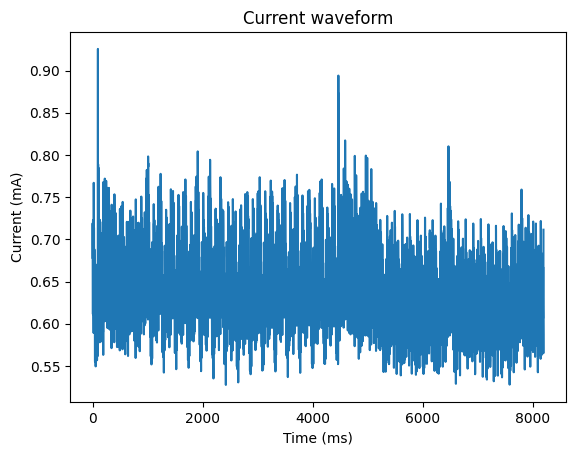

In [46]:
plotCurrentWaveform(M[0])

Byte 0: Guess = 57, Correlation = 0.4305
Byte 1: Guess = 70, Correlation = 0.3697
Byte 2: Guess = 8f, Correlation = 0.4419
Byte 3: Guess = 87, Correlation = 0.4115
Byte 4: Guess = d0, Correlation = 0.4052
Byte 5: Guess = 2f, Correlation = 0.3784
Byte 6: Guess = 10, Correlation = 0.3906
Byte 7: Guess = 33, Correlation = 0.4041
Byte 8: Guess = be, Correlation = 0.4671
Byte 9: Guess = 71, Correlation = 0.4034
Byte 10: Guess = 6f, Correlation = 0.3871
Byte 11: Guess = de, Correlation = 0.4597
Byte 12: Guess = 46, Correlation = 0.3631
Byte 13: Guess = d8, Correlation = 0.3638
Byte 14: Guess = 9f, Correlation = 0.3758
Byte 15: Guess = 41, Correlation = 0.4136


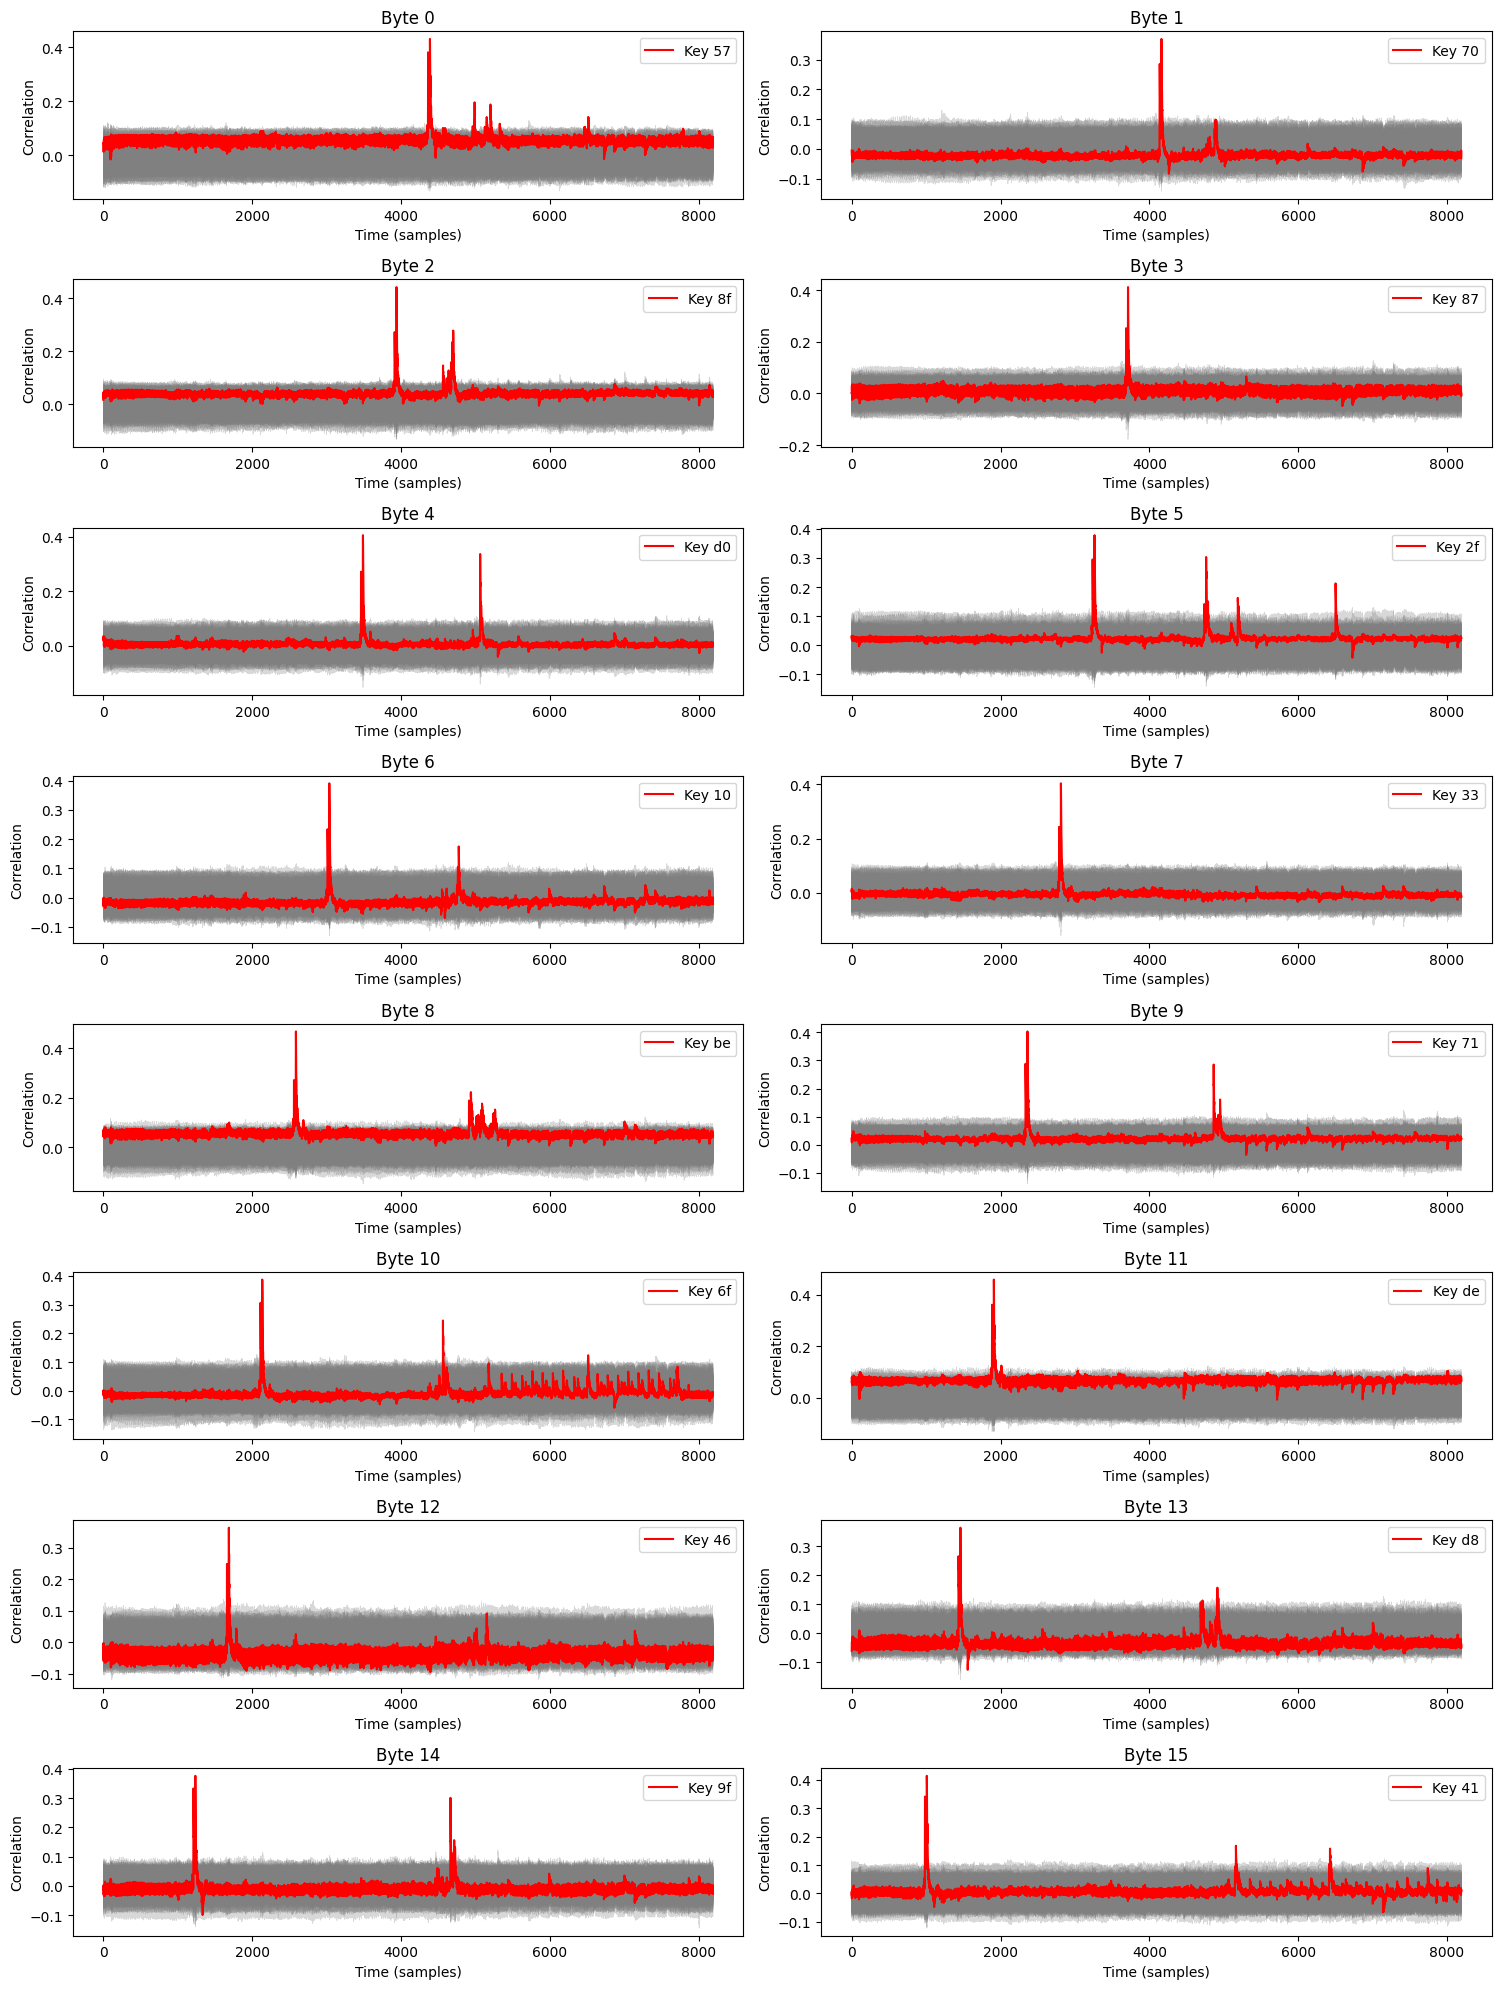

Recovered key: 57708f87d02f1033be716fde46d89f41


In [47]:
key_bytes, key_scores = cpa_attack(plaintexts, M)
key_hex = "".join(f"{b:02x}" for b in key_bytes)
print(f"Recovered key: {key_hex}")

In [56]:
import aes_encrypt

zero_plaintext = 0x0
expected_encryption = Encryption_Board.encrypt(zero_plaintext)
obtained_encryption = aes_encrypt.encrypt(zero_plaintext, int(key_hex, 16))

print(f"Expected encryption of 0x0: {expected_encryption:032x}")
print(f"Obtained encryption of 0x0 with recovered key: {obtained_encryption:032x}")
print("Verification successful!" if expected_encryption == obtained_encryption else "Verification failed!")

Expected encryption of 0x0: 1fc8c3dd271a794f72ac23b5504d51c3
Obtained encryption of 0x0 with recovered key: 1fc8c3dd271a794f72ac23b5504d51c3
Verification successful!


In [57]:
# Save powertraces and plaintexts for later use
import pickle
with open("measured_powertraces.pickle", "wb") as f:
    pickle.dump((plaintexts, M), f)